## Esempio 2 per il progetto:
environment gridworld con moving obstacles (reward function che si modifica)

In [11]:
import gymnasium as gym
import numpy as np
from typing import Optional

In [12]:
class GridWorldEnMovingObstacle(gym.Env):
    def __init__(self, size: int = 5, render_mode: str = None):
        self.size = size #size of the world defined
        self.render_mode = render_mode
        # the inizialization will be reset randomly with the function reset()
        self.agent_location = np.array([-1,-1], dtype=np.int32)
        self.target_location = np.array([-1,-1], dtype=np.int32)
        self.reward_function = np.zeros((size,size))


        self.observation_space = gym.spaces.Dict(
            {
                "agent": gym.spaces.Box(0, size-1, shape=(2,), dtype=int), # [x,y] coordinates
                "target": gym.spaces.Box(0, size-1, shape=(2,), dtype=int), 
            }
        )

        self.action_space = gym.spaces.Discrete(4) #4 directions are available

        self.action_to_direction = {
            0: np.array([0, 1]),   # Move right (column + 1)
            1: np.array([-1, 0]),  # Move up (row - 1)
            2: np.array([0, -1]),  # Move left (column - 1)
            3: np.array([1, 0]),   # Move down (row + 1)
        }
    
    def get_obs(self):
        return {"agent": self.agent_location, "target":  self.target_location}
    
    def get_info(self):
        return {
            "distance": np.linalg.norm(
                self.agent_location - self.target_location, ord=1
            )
        }
    def reset(self, seed: Optional[int] = None, options:Optional[dict] = None):

        super().reset(seed=seed) #important to seed the random number generator

        self.agent_location = np.array([4, 0], dtype=np.int32)
        self.target_location = np.array([0, 4], dtype=np.int32)
    
        # Inizializza la matrice dei reward pulita ogni volta
        self.reward_function = np.zeros((self.size, self.size))
        self.reward_function[2, 4] = -10 # L'ostacolo parte da qui


        observation = self.get_obs()
        info = self.get_info()

        return observation, info

    @staticmethod # Aggiungi questo decoratore
    def update_reward(reward_function):
        # Creiamo una copia per non sovrascrivere mentre iteriamo
        new_reward_map = np.zeros_like(reward_function)
        rows, cols = reward_function.shape
    
        for i in range(rows):
            for j in range(cols):
                if reward_function[i, j] == -10:
                    # Sposta a sinistra (j-1) se possibile, altrimenti resta lì
                    new_j = max(0, j - 1)
                    new_reward_map[i, new_j] = -10
        return new_reward_map
    
    def step(self, action):
        direction = self.action_to_direction[action]
        self.agent_location = np.clip(self.agent_location + direction, 0, self.size - 1)

        terminated = bool(np.array_equal(self.agent_location, self.target_location)) # Forza bool
        truncated = False 

        # IMPORTANTE: Calcola il reward PRIMA di far muovere l'ostacolo 
        # Altrimenti l'agente viene punito per dove l'ostacolo SARÀ, non dove È.
        current_reward = float(self.reward_function[self.agent_location[0], self.agent_location[1]])
        reward = 1.0 if terminated else current_reward
    
        # Aggiorna l'ostacolo per il prossimo stato
        self.reward_function = self.update_reward(self.reward_function)
    
        observation = self.get_obs()
    
        # Crea un info pulito. .item() converte il valore NumPy in un float nativo Python
        info = {"distance": float(np.linalg.norm(self.agent_location - self.target_location, ord=1))}

        return observation, float(reward), terminated, truncated, info

    def render(self): #Advanced feature for rendering
        """Render the environment for human viewing."""
        if self.render_mode == "human" or 1==1:
            # Print a simple ASCII representation
            for y in range(self.size - 1, -1, -1):  # Top to bottom
                row = ""
                for x in range(self.size):
                    if np.array_equal([x, y], self.agent_location):
                      row += "A "  # Agent
                    elif np.array_equal([x, y], self.target_location):
                        row += "T "  # Target
                    else:
                        row += ". "  # Empty
                print(row)
            print()


In [13]:
gym.register(
    id = "gymnasium_env/GridWorldMovingObstacle-v0",
    entry_point = GridWorldEnMovingObstacle,
    max_episode_steps = 500, #prevent infinite episodes
)

c:\Users\39324\anaconda3\envs\naml_libraries\lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment gymnasium_env/GridWorldMovingObstacle-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [28]:
from gymnasium.utils.env_checker import check_env
env = gym.make("gymnasium_env/GridWorldMovingObstacle-v0", size=5) #Grid World 10*10

try:
    check_env(env)
    print("Environment passes all checks!")
except Exception as e:
    print(f"Environment has issues: {e}")

Environment passes all checks!


c:\Users\39324\anaconda3\envs\naml_libraries\lib\site-packages\gymnasium\utils\env_checker.py:384: UserWarning: WARN: The environment (<TimeLimit<OrderEnforcing<PassiveEnvChecker<GridWorldEnMovingObstacle<gymnasium_env/GridWorldMovingObstacle-v0>>>>>) is different from the unwrapped version (<GridWorldEnMovingObstacle<gymnasium_env/GridWorldMovingObstacle-v0>>). This could effect the environment checker as the environment most likely has a wrapper applied to it. We recommend using the raw environment for `check_env` using `env.unwrapped`.
  logger.warn(
c:\Users\39324\anaconda3\envs\naml_libraries\lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be int64, actual type: int32
  logger.warn(
c:\Users\39324\anaconda3\envs\naml_libraries\lib\site-packages\gymnasium\utils\passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dt

In [29]:
from collections import defaultdict

In [30]:
class GridWorldAgent:
    def __init__(
            self,
            env: gym.Env,
            learning_rate: float,
            initial_epsilon: float,
            epsilon_decay:float,
            final_epsilon: float,
            discount_factor: float = 0.95,
    ):
        self.env = env
        self.learning_rate = learning_rate
        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon
        self.discount_factor = discount_factor

        self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        self.training_error = []
    
    def state_to_key(self, obs: dict[str, np.ndarray]) -> tuple:
        return (
            tuple(obs["agent"]),
            tuple(obs["target"])
        )
    
    def get_action(self, obs: dict[str, np.ndarray]) -> int:
        state = self.state_to_key(obs) #make the observation hashable

        if np.random.random()< self.epsilon:
            return self.env.action_space.sample()
        else:
            return int(np.argmax(self.q_values[state]))
    
    def update(
            self,
            obs: dict[str, np.ndarray],
            action: int,
            reward: float,
            terminated: bool,
            next_obs: dict[str, np.ndarray],
    ):
        state = self.state_to_key(obs)
        next_state = self.state_to_key(next_obs)
        future_q_value = (not terminated) * np.max(self.q_values[next_state])
        target = reward + self.discount_factor * future_q_value
        temporal_difference = target - self.q_values[state][action]
        
        self.q_values[state][action] += self.learning_rate * temporal_difference

        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        """Reduce exploration rate after each episode."""
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)
    


In [31]:
learning_rate = 0.01
n_episodes = 500
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01

# using the gridWorld environment
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = GridWorldAgent(
    env = env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [18]:
from tqdm import tqdm

for episode in tqdm(range(n_episodes)):
    # start a new hand
    obs, info = env.reset()
    done = False

    #Play a complete episode
    while not done:
        action = agent.get_action(obs) #follows the eps-greedy action selection strategy
        next_obs, reward, terminated, truncated, info = env.step(action)
        # nb: the observation are in this implementation like the state of the agent, he observe its state   

        agent.update(obs, action, reward, terminated, next_obs) #agent learn from the results of the environment
        obs = next_obs 
        done = terminated or truncated


    agent.decay_epsilon()

100%|██████████| 500/500 [00:01<00:00, 337.22it/s]


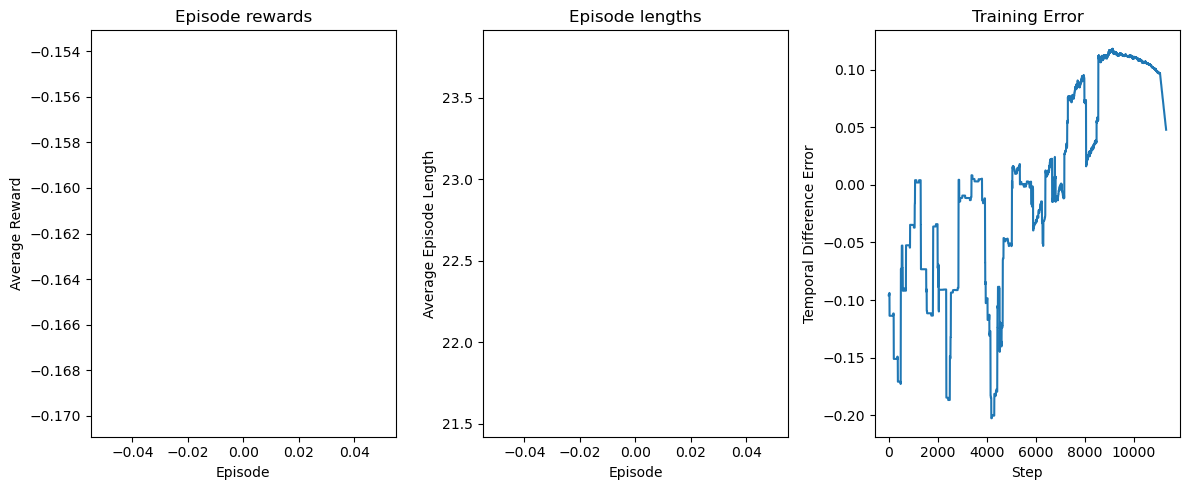

In [19]:
from matplotlib import pyplot as plt

def get_moving_avgs(arr, window, convolution_mode):
    """Compute moving average to smooth noisy data."""
    return np.convolve(
        np.array(arr).flatten(),
        np.ones(window),
        mode=convolution_mode
    ) / window

# Smooth over a 500-episode window
rolling_length = 500
fig, axs = plt.subplots(ncols=3, figsize=(12, 5))

# Episode rewards (win/loss performance)
axs[0].set_title("Episode rewards")
reward_moving_average = get_moving_avgs(
    env.return_queue,
    rolling_length,
    "valid"
)
axs[0].plot(range(len(reward_moving_average)), reward_moving_average)
axs[0].set_ylabel("Average Reward")
axs[0].set_xlabel("Episode")

# Episode lengths (how many actions per hand)
axs[1].set_title("Episode lengths")
length_moving_average = get_moving_avgs(
    env.length_queue,
    rolling_length,
    "valid"
)
axs[1].plot(range(len(length_moving_average)), length_moving_average)
axs[1].set_ylabel("Average Episode Length")
axs[1].set_xlabel("Episode")

# Training error (how much we're still learning)
axs[2].set_title("Training Error")
training_error_moving_average = get_moving_avgs(
    agent.training_error,
    rolling_length,
    "same"
)
axs[2].plot(range(len(training_error_moving_average)), training_error_moving_average)
axs[2].set_ylabel("Temporal Difference Error")
axs[2].set_xlabel("Step")

plt.tight_layout()
plt.show()

In [32]:
# Test the trained agent
def test_agent(agent, env, num_episodes=1000):
    """Test agent performance without learning or exploration."""
    total_rewards = []
    # Temporarily disable exploration for testing
    old_epsilon = agent.epsilon
    agent.epsilon = 0.0  # Pure exploitation

    for _ in range(num_episodes): #number of episodes = game the agent plays
        obs, info = env.reset()
        episode_reward = 0
        done = False
        path = [tuple(map(int, obs["agent"]))]


        while not done:  # run an episode
            action = agent.get_action(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            done = terminated or truncated
            path.append(tuple(map(int, obs["agent"])))

        path_str = " -> ".join([f"({r},{c})" for r, c in path])
        target_clean = tuple(map(int, env.unwrapped.target_location))
        print(f"🎯 Target: {target_clean} | 🛤️  Percorso: {path_str}")
        total_rewards.append(episode_reward)
        path = []

    # Restore original epsilon
    agent.epsilon = old_epsilon

    win_rate = np.mean(np.array(total_rewards) > 0)
    average_reward = np.mean(total_rewards)

    print(f"Test Results over {num_episodes} episodes:")
    print(f"Win Rate: {win_rate:.1%}")
    print(f"Average Reward: {average_reward:.3f}")
    print(f"Standard Deviation: {np.std(total_rewards):.3f}")

# Test your agent
test_agent(agent, env)

🎯 Target: (0, 4) | 🛤️  Percorso: (4,0) -> (4,1) -> (4,2) -> (4,3) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4) -> (4,4

KeyboardInterrupt: 

In [ ]:
action_map = {1: '→', 0: '↑', 3: '←', 2: '↓'}

for state, q_values in agent.q_values.items():
    agent_pos, target_pos = state
    agent_pos = tuple(int(x) for x in agent_pos)
    target_pos = tuple(int(x) for x in target_pos)
    best_action = int(np.argmax(q_values))
    print(f"Agent: {agent_pos}, Target: {target_pos} -> Best: {action_map[best_action]}, Q: {q_values.round(3)}")